<a href="https://colab.research.google.com/github/sharunraj14/ICT_Projects/blob/main/Deep_Learning_ICT_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 1.1 — Data Loading & Exploratory Data Analysis (EDA)
Fetching the california housing data and doing an EDA

In [1]:
#Importing Frameworks and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Fetching data from sklearn
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

In [3]:
#shape and head
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
X.head(10)

Features shape: (20640, 8)
Target shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25


In [4]:
display(X.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


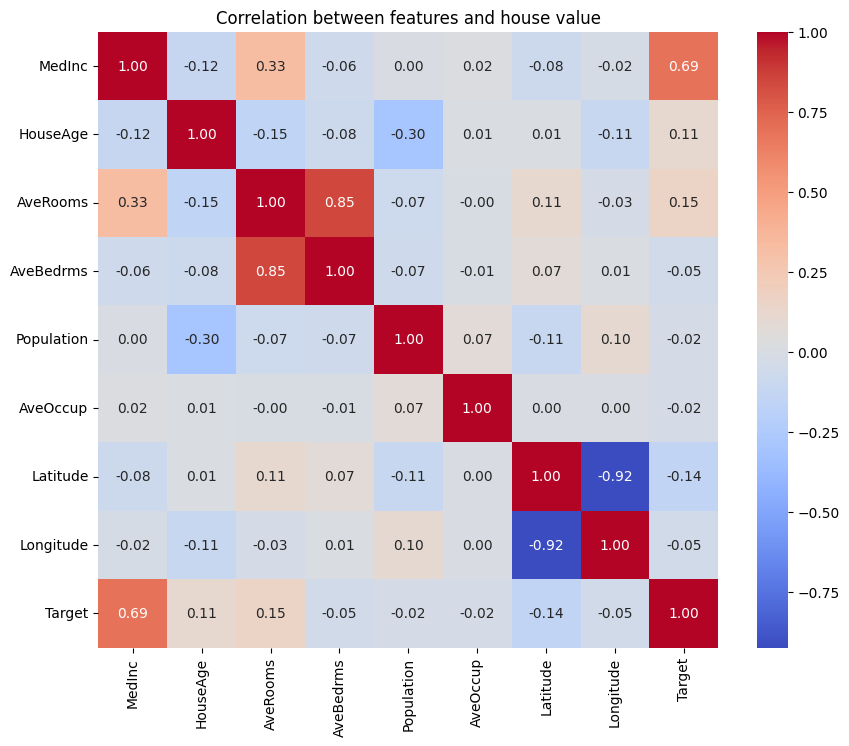

In [5]:
#Checking Correlation
plt.figure(figsize=(10, 8))
sns.heatmap(X.assign(Target=y).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between features and house value')
plt.show()

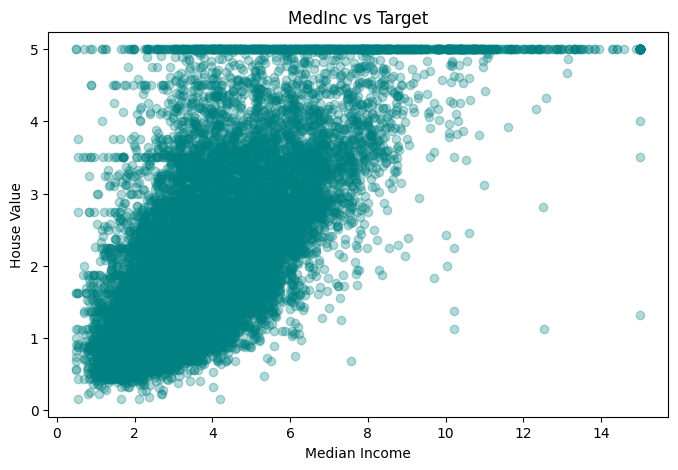

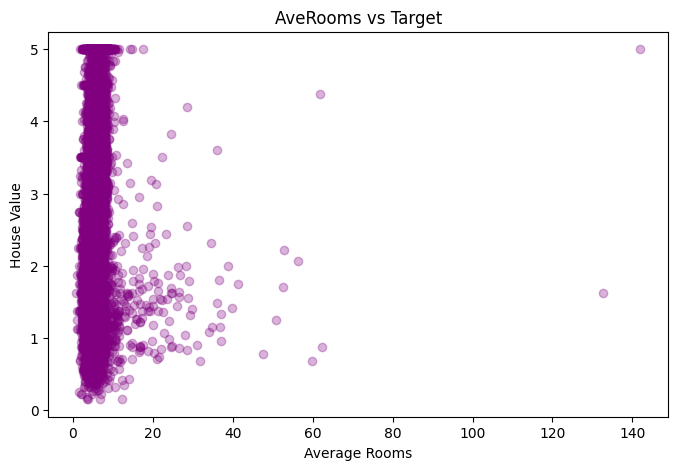

In [6]:
#Income and Price Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(X['MedInc'], y, alpha=0.3, color='teal')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.title('MedInc vs Target')
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(X['AveRooms'], y, alpha=0.3, color='purple')
plt.xlabel("Average Rooms")
plt.ylabel("House Value")
plt.title("AveRooms vs Target")
plt.show()

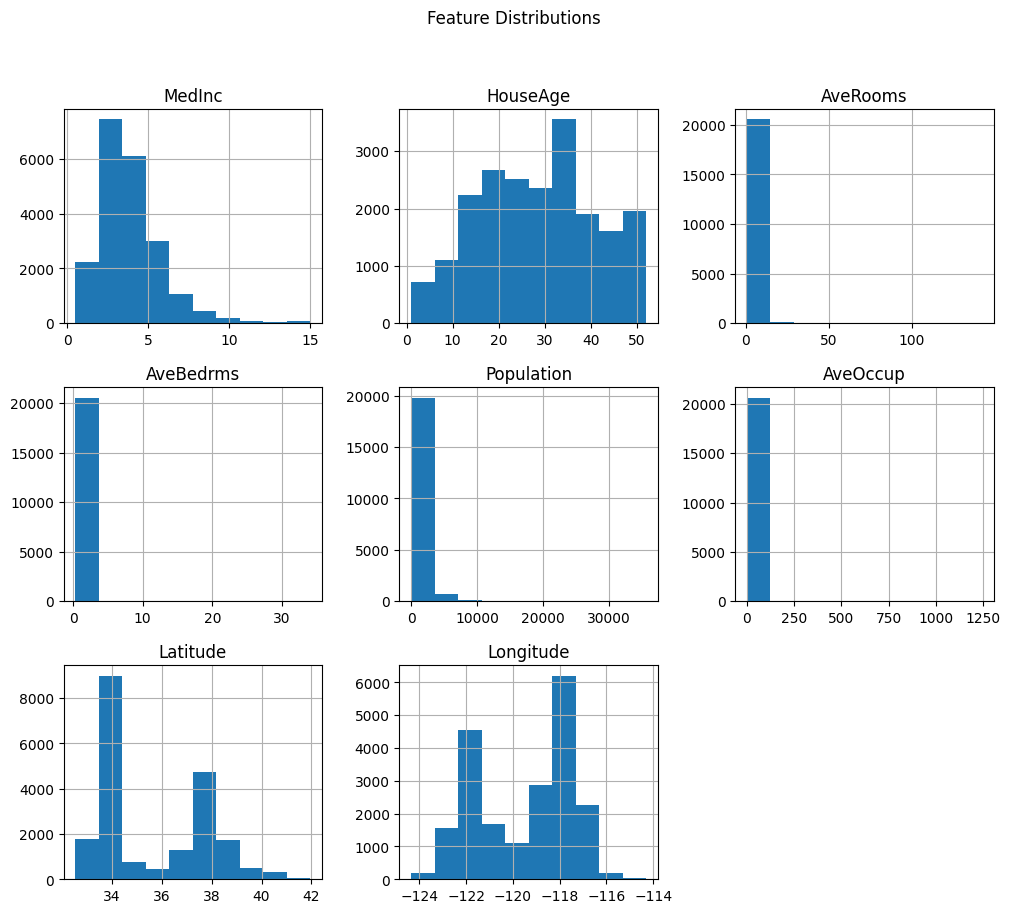

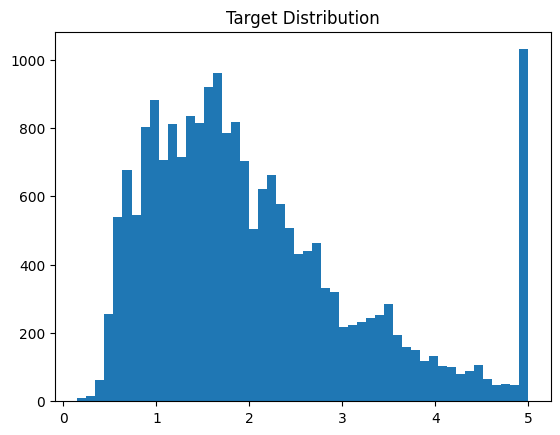

In [7]:
#Histogram
X.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

plt.hist(y, bins=50)
plt.title("Target Distribution")
plt.show()

#Stage 1.2 — Data Preprocessing
Splitting the data and giving random state value of 42

The dataset is divided into three subsets:

Training set 70%  
Validation set 15%  
Test set 15%

Training set is used to learn the model parameters. Validation set is used during training for performance checking and to detect overfitting. Test set is kept separate and is only used for final evaluation.


In [8]:
# 70/15/15 split with random state 42
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
# Splitting 85% remaining into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42)

standard scalar is used because features have different ranges, Scaler is fitted to training data only and it is applied to validation and test data

In [9]:
#Scaling only Training Dtata
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 14456, Val size: 3088, Test size: 3096


# Stage 1.3 — Model Architecture Design

fully connected neural network is implemented using Keras sequential api. It consist of 3 hidden layers with relu. relu is used because of its non linearity. Dropout is introduced to prevent overfitting. output layers contains only one neuron since the task is regression where it is prediction and its a continuous value.
Loss Function: I chose Huber Loss. it's selected because it behaves like Mean Squared Error (MSE) for small errors but like Mean Absolute Error (MAE) for large errors. This makes it more robust to outliers in the housing data

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Setting seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.1), # Regularization choice
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

# Huber loss for handling outliers
model.compile(optimizer='adam', loss='huber', metrics=['mae', 'mse'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

#Stage 1.4 — Model Training

model is trained for multiple epochs using training data, early stopping was also used to monitor validation loss and stop overfitting. and check point was also used to save best performing model during training.

In [11]:
# Callbacks: stop early if val_loss is not improving for 10 epochs
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = tf.keras.callbacks.ModelCheckpoint('best_regression_model.keras', save_best_only=True)

# Training for 50 epochs
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.2920 - mae: 0.5963 - mse: 0.7703 - val_loss: 0.1770 - val_mae: 0.4510 - val_mse: 0.4036
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1826 - mae: 0.4553 - mse: 0.4259 - val_loss: 0.1613 - val_mae: 0.4290 - val_mse: 0.3663
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1707 - mae: 0.4375 - mse: 0.3981 - val_loss: 0.1565 - val_mae: 0.4155 - val_mse: 0.3658
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1634 - mae: 0.4268 - mse: 0.3749 - val_loss: 0.1473 - val_mae: 0.4032 - val_mse: 0.3348
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1569 - mae: 0.4157 - mse: 0.3586 - val_loss: 0.1435 - val_mae: 0.3949 - val_mse: 0.3276
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1507 - mae: 0.4058 - mse: 0.3439 - val_loss: 0.1382 - val_mae: 0.3884 - val_mse: 0.3121
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1461 - mae: 0.3959 - mse: 0.3333 - val

#Stage 1.5 — Plotting & Interpreting Training Curves

Training and validation loss were plotted for epochs to see how the model learns.

If both curves decrease together and gets stable , it shows that model is learning properly.

If training loss continues decreasing while validation loss increases, it indicates overfitting. If both curves remain high, it indicates underfitting.
Convergence: The model appears to converge around epoch approx 50, where the validation loss stops significantly decreasing.

Model Fit: Based on the plot, the model shows a Good Fit. Both the training and validation loss decrease together and plateau at similar values without a widening gap

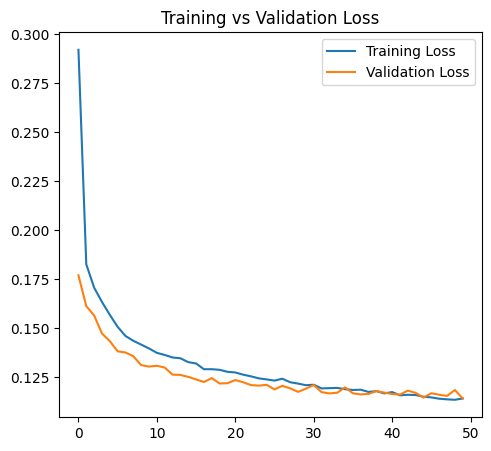

In [12]:
# Loss Curve plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

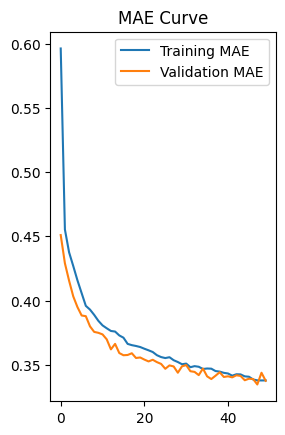

In [13]:
# MAE curve plotting
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE Curve')
plt.legend()
plt.show()

#Stage 1.6 — Model Evaluation & Analysis

Evaluating final trained model on test dataset

the final evaluation on the held-out test set resulted in an MAE of 0.26403185725212097. This result is consistent with my validation metrics, proving the model generalizes well.

an improvement which can be made is to perform feature engineering to combine related variables

In [14]:
#Evaluating test set
test_loss, test_mae, test_mse = model.evaluate(X_test_scaled, y_test)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)
print("Test MSE:", test_mse)

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1175 - mae: 0.3462 - mse: 0.2632
Test Loss: 0.11752405762672424
Test MAE: 0.34617146849632263
Test MSE: 0.2631857097148895


In [15]:
#Prediction
y_pred = model.predict(X_test_scaled).flatten()

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


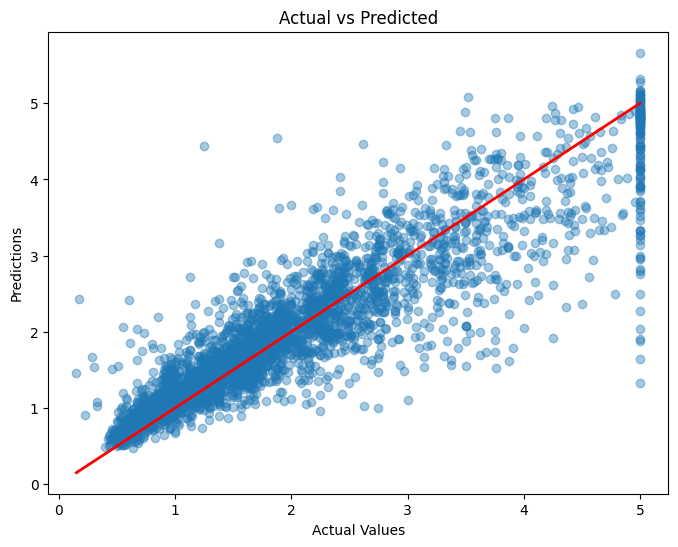

In [16]:
#Actual plot and predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predictions')
plt.title('Actual vs Predicted')
plt.show()